---
## 1. Setup & Import Libraries

Import các thư viện cần thiết cho EDA. Sử dụng:
- `pandas`: Data manipulation
- `matplotlib/seaborn`: Visualization
- `collections`: Thống kê
- `transformers`: Tokenization analysis

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
import warnings
import re

# Optional: For tokenization analysis
try:
    from transformers import AutoTokenizer
    HAS_TRANSFORMERS = True
except ImportError:
    HAS_TRANSFORMERS = False
    print("⚠️ transformers not installed. Token analysis will be skipped.")

warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")

/home/minhquana/miniconda3/envs/llm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported successfully!


---
## 2. Load Data

### Format SFT Dataset:
```json
{
    "messages": [
        {"role": "system", "content": "..."},
        {"role": "user", "content": "..."},
        {"role": "assistant", "content": "..."}
    ]
}
```

### Best Practice:
- Validate JSON format cho từng line
- Kiểm tra required fields: `messages`, `role`, `content`
- Track số lượng invalid entries

In [56]:
# Path configuration
DATA_PATH = Path("../data/final_sft_cleaned.jsonl")

def load_sft_data(filepath: Path) -> tuple[list[dict], list[int]]:
    """
    Load SFT data from JSONL file with validation.
    
    Returns:
        - data: List of valid conversation dictionaries
        - invalid_lines: List of line numbers with invalid data
    """
    data = []
    invalid_lines = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f, 1):
            try:
                entry = json.loads(line.strip())
                # Validate structure
                if 'messages' in entry and isinstance(entry['messages'], list):
                    if all('role' in msg and 'content' in msg for msg in entry['messages']):
                        data.append(entry)
                    else:
                        invalid_lines.append(idx)
                else:
                    invalid_lines.append(idx)
            except json.JSONDecodeError:
                invalid_lines.append(idx)
    
    return data, invalid_lines

# Load data
sft_data, invalid_lines = load_sft_data(DATA_PATH)

print(f"📁 Data loaded from: {DATA_PATH}")
print(f"✅ Valid entries: {len(sft_data):,}")
print(f"❌ Invalid entries: {len(invalid_lines)}")

if invalid_lines:
    print(f"⚠️ Invalid line numbers (first 10): {invalid_lines[:10]}")

📁 Data loaded from: ../data/final_sft_cleaned.jsonl
✅ Valid entries: 10,085
❌ Invalid entries: 0


---
## 3. Basic Statistics

### Phân tích cấu trúc conversation:
- Số lượng messages per conversation
- Distribution của roles (system, user, assistant)
- Đảm bảo format chuẩn cho SFT

In [57]:
# Extract statistics
stats = {
    'num_messages': [],  # Number of messages per conversation
    'has_system': [],    # Whether conversation has system message
    'num_turns': [],     # Number of user-assistant turns
    'roles': []          # All roles in dataset
}

for entry in sft_data:
    messages = entry['messages']
    stats['num_messages'].append(len(messages))
    
    roles = [msg['role'] for msg in messages]
    stats['roles'].extend(roles)
    stats['has_system'].append('system' in roles)
    
    # Count user-assistant turns
    user_count = roles.count('user')
    assistant_count = roles.count('assistant')
    stats['num_turns'].append(min(user_count, assistant_count))

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Metric': [
        'Total Conversations',
        'Avg Messages/Conversation',
        'Min Messages',
        'Max Messages',
        'Conversations with System Prompt',
        'Avg Turns (User-Assistant pairs)',
        'Single Turn Conversations',
        'Multi-Turn Conversations'
    ],
    'Value': [
        len(sft_data),
        f"{np.mean(stats['num_messages']):.2f}",
        min(stats['num_messages']),
        max(stats['num_messages']),
        f"{sum(stats['has_system']):,} ({100*sum(stats['has_system'])/len(sft_data):.1f}%)",
        f"{np.mean(stats['num_turns']):.2f}",
        sum(1 for t in stats['num_turns'] if t == 1),
        sum(1 for t in stats['num_turns'] if t > 1)
    ]
})

print("📊 Dataset Summary:")
print(summary_df.to_string(index=False))

📊 Dataset Summary:
                          Metric           Value
             Total Conversations           10085
       Avg Messages/Conversation            3.00
                    Min Messages               3
                    Max Messages               3
Conversations with System Prompt 10,085 (100.0%)
Avg Turns (User-Assistant pairs)            1.00
       Single Turn Conversations           10085
        Multi-Turn Conversations               0


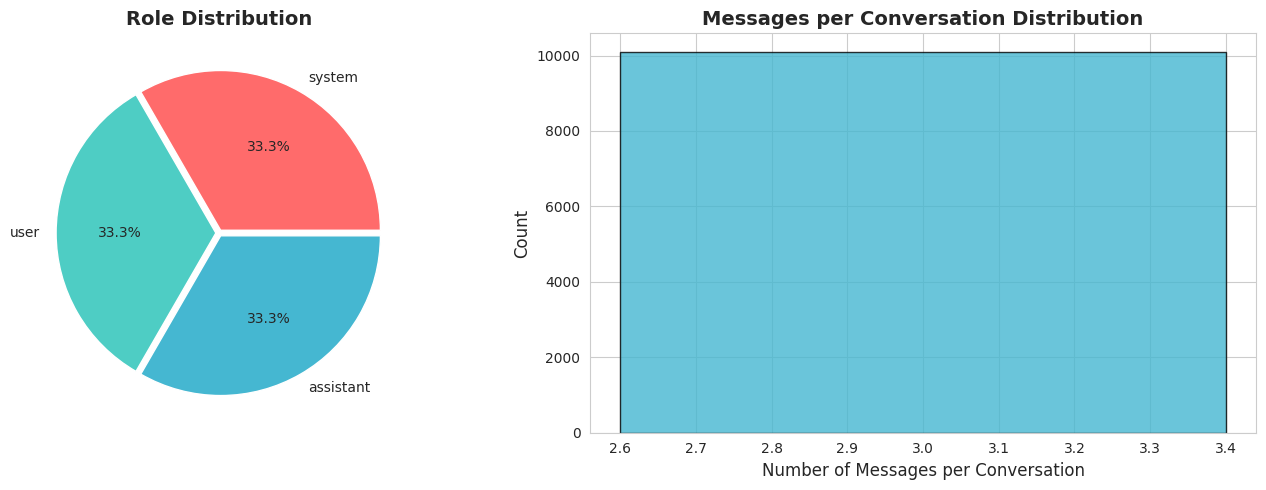


📈 Role Counts:
  - system: 10,085
  - user: 10,085
  - assistant: 10,085


In [58]:
# Role distribution
role_counts = Counter(stats['roles'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart for role distribution
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0].pie(
    role_counts.values(), 
    labels=role_counts.keys(),
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.02] * len(role_counts)
)
axes[0].set_title('Role Distribution', fontsize=14, fontweight='bold')

# Bar chart for messages per conversation
msg_counts = Counter(stats['num_messages'])
x = sorted(msg_counts.keys())
y = [msg_counts[k] for k in x]

axes[1].bar(x, y, color='#45B7D1', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Number of Messages per Conversation', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Messages per Conversation Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📈 Role Counts:")
for role, count in role_counts.items():
    print(f"  - {role}: {count:,}")

---
## 4. Text Length Analysis

### Mục đích:
- Phân tích độ dài character/word cho từng role
- Xác định outliers (quá ngắn hoặc quá dài)
- Chuẩn bị cho tokenization và max_length setting

### Best Practices:
- User messages thường ngắn (câu hỏi)
- Assistant responses nên đủ chi tiết nhưng không quá dài
- System prompts nên consistent

In [59]:
# Extract text lengths by role
length_data = {
    'system': {'char': [], 'word': []},
    'user': {'char': [], 'word': []},
    'assistant': {'char': [], 'word': []}
}

# Total conversation lengths
total_char_lengths = []
total_word_lengths = []

for entry in sft_data:
    total_chars = 0
    total_words = 0
    
    for msg in entry['messages']:
        role = msg['role']
        content = msg['content']
        
        char_len = len(content)
        word_len = len(content.split())
        
        if role in length_data:
            length_data[role]['char'].append(char_len)
            length_data[role]['word'].append(word_len)
        
        total_chars += char_len
        total_words += word_len
    
    total_char_lengths.append(total_chars)
    total_word_lengths.append(total_words)

# Create summary table
length_summary = []
for role in ['system', 'user', 'assistant']:
    if length_data[role]['char']:
        length_summary.append({
            'Role': role.capitalize(),
            'Count': len(length_data[role]['char']),
            'Avg Chars': f"{np.mean(length_data[role]['char']):.1f}",
            'Median Chars': f"{np.median(length_data[role]['char']):.1f}",
            'Min Chars': min(length_data[role]['char']),
            'Max Chars': max(length_data[role]['char']),
            'Avg Words': f"{np.mean(length_data[role]['word']):.1f}",
            'Std Words': f"{np.std(length_data[role]['word']):.1f}"
        })

length_df = pd.DataFrame(length_summary)
print("📏 Text Length Statistics by Role:")
print(length_df.to_string(index=False))
# length_df

📏 Text Length Statistics by Role:
     Role  Count Avg Chars Median Chars  Min Chars  Max Chars Avg Words Std Words
   System  10085     356.0        356.0        356        356      82.0       0.0
     User  10085      72.1         63.0         10        481      16.4       8.3
Assistant  10085     825.2        650.0         23       4797     181.2     144.1


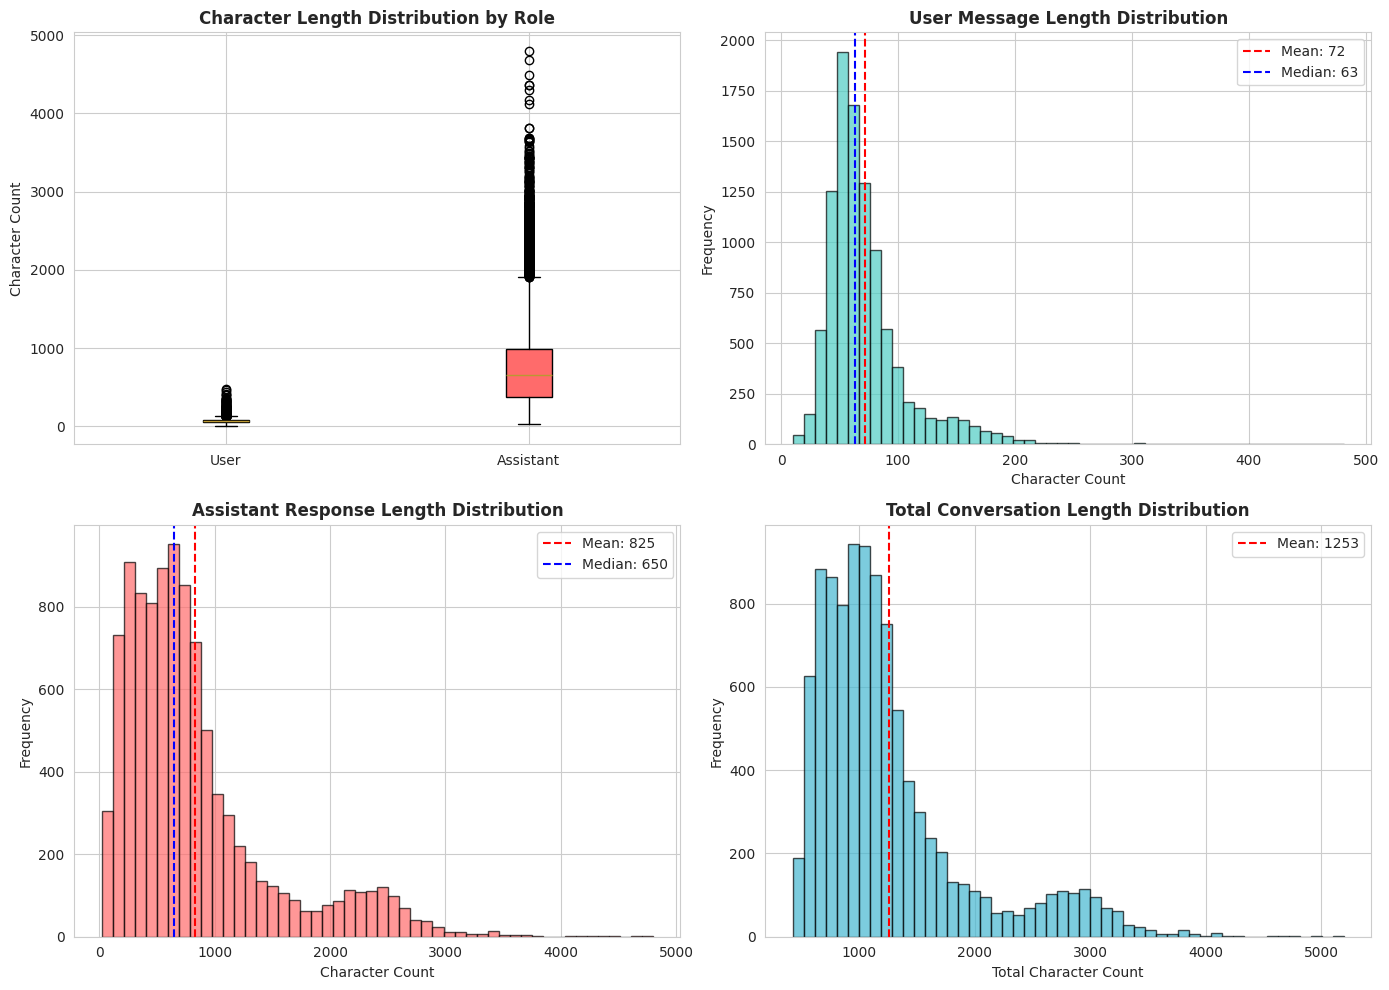

In [60]:
# Visualize text length distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Character length distribution by role
roles_with_data = [r for r in ['user', 'assistant'] if length_data[r]['char']]
char_data = [length_data[r]['char'] for r in roles_with_data]

bp1 = axes[0, 0].boxplot(char_data, labels=[r.capitalize() for r in roles_with_data], patch_artist=True)
colors = ['#4ECDC4', '#FF6B6B']
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
axes[0, 0].set_ylabel('Character Count')
axes[0, 0].set_title('Character Length Distribution by Role', fontweight='bold')

# 2. Histogram of user message lengths
axes[0, 1].hist(length_data['user']['char'], bins=50, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(np.mean(length_data['user']['char']), color='red', linestyle='--', label=f"Mean: {np.mean(length_data['user']['char']):.0f}")
axes[0, 1].axvline(np.median(length_data['user']['char']), color='blue', linestyle='--', label=f"Median: {np.median(length_data['user']['char']):.0f}")
axes[0, 1].set_xlabel('Character Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('User Message Length Distribution', fontweight='bold')
axes[0, 1].legend()

# 3. Histogram of assistant response lengths
axes[1, 0].hist(length_data['assistant']['char'], bins=50, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(np.mean(length_data['assistant']['char']), color='red', linestyle='--', label=f"Mean: {np.mean(length_data['assistant']['char']):.0f}")
axes[1, 0].axvline(np.median(length_data['assistant']['char']), color='blue', linestyle='--', label=f"Median: {np.median(length_data['assistant']['char']):.0f}")
axes[1, 0].set_xlabel('Character Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Assistant Response Length Distribution', fontweight='bold')
axes[1, 0].legend()

# 4. Total conversation length
axes[1, 1].hist(total_char_lengths, bins=50, color='#45B7D1', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(np.mean(total_char_lengths), color='red', linestyle='--', label=f"Mean: {np.mean(total_char_lengths):.0f}")
axes[1, 1].set_xlabel('Total Character Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Total Conversation Length Distribution', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

---
## 5. Token Analysis (Optional)

### Mục đích:
- Đếm số tokens thực tế sau tokenization
- Xác định max_length phù hợp cho training
- Phát hiện conversations vượt quá context length

### Recommendation:
- Sử dụng tokenizer của model sẽ dùng để train

In [71]:
if HAS_TRANSFORMERS:
    # Load tokenizer - adjust model name as needed
    MODEL_NAME = "unsloth/Qwen3-4B-Instruct-2507"  # Change to your target model
    
    try:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
        print(f"✅ Loaded tokenizer: {MODEL_NAME}")
        print(f"   Vocab size: {tokenizer.vocab_size:,}")
        
        # Analyze token counts
        token_counts = []
        
        for entry in sft_data:
            # Format as chat template if available
            try:
                text = tokenizer.apply_chat_template(
                    entry['messages'], 
                    tokenize=False, 
                    add_generation_prompt=False
                )
            except:
                # Fallback: concatenate all content
                text = "\n".join([msg['content'] for msg in entry['messages']])
            
            tokens = tokenizer.encode(text)
            token_counts.append(len(tokens))
        
        # Statistics
        print(f"\n📊 Token Statistics:")
        print(f"   Mean tokens: {np.mean(token_counts):.1f}")
        print(f"   Median tokens: {np.median(token_counts):.1f}")
        print(f"   Min tokens: {min(token_counts)}")
        print(f"   Max tokens: {max(token_counts)}")
        print(f"   95th percentile: {np.percentile(token_counts, 95):.0f}")
        print(f"   99th percentile: {np.percentile(token_counts, 99):.0f}")
        
        # Check for potential issues
        MAX_LENGTH_THRESHOLD = 1500
        over_threshold = sum(1 for t in token_counts if t > MAX_LENGTH_THRESHOLD)
        print(f"\n⚠️ Conversations exceeding {MAX_LENGTH_THRESHOLD} tokens: {over_threshold} ({100*over_threshold/len(token_counts):.2f}%)")
        
    except Exception as e:
        print(f"❌ Failed to load tokenizer: {e}")
        token_counts = None
else:
    print("⏭️ Skipping token analysis (transformers not installed)")
    token_counts = None

✅ Loaded tokenizer: unsloth/Qwen3-4B-Instruct-2507
   Vocab size: 151,643

📊 Token Statistics:
   Mean tokens: 372.8
   Median tokens: 319.0
   Min tokens: 137
   Max tokens: 1479
   95th percentile: 845
   99th percentile: 997

⚠️ Conversations exceeding 1500 tokens: 0 (0.00%)


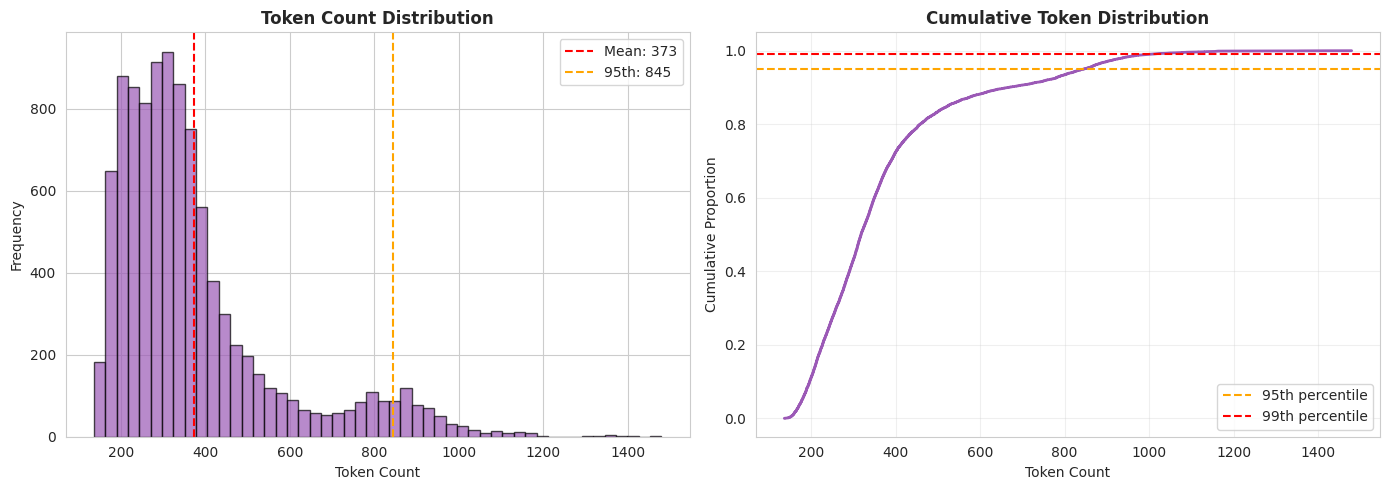


💡 Recommended max_length for training: 997
   This covers 99% of conversations without truncation.


In [62]:
if token_counts:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(token_counts, bins=50, color='#9B59B6', edgecolor='black', alpha=0.7)
    axes[0].axvline(np.mean(token_counts), color='red', linestyle='--', label=f"Mean: {np.mean(token_counts):.0f}")
    axes[0].axvline(np.percentile(token_counts, 95), color='orange', linestyle='--', label=f"95th: {np.percentile(token_counts, 95):.0f}")
    axes[0].set_xlabel('Token Count')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Token Count Distribution', fontweight='bold')
    axes[0].legend()
    
    # Cumulative distribution
    sorted_tokens = np.sort(token_counts)
    cumulative = np.arange(1, len(sorted_tokens) + 1) / len(sorted_tokens)
    axes[1].plot(sorted_tokens, cumulative, color='#9B59B6', linewidth=2)
    axes[1].axhline(0.95, color='orange', linestyle='--', label='95th percentile')
    axes[1].axhline(0.99, color='red', linestyle='--', label='99th percentile')
    axes[1].set_xlabel('Token Count')
    axes[1].set_ylabel('Cumulative Proportion')
    axes[1].set_title('Cumulative Token Distribution', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Recommendation
    recommended_max_length = int(np.percentile(token_counts, 99))
    print(f"\n💡 Recommended max_length for training: {recommended_max_length}")
    print(f"   This covers 99% of conversations without truncation.")

---
## 6. System Prompt Analysis

### Mục đích:
- Kiểm tra consistency của system prompts
- Đảm bảo tất cả conversations có cùng system prompt (nếu cần)
- Phát hiện variations hoặc missing system prompts

In [63]:
# Extract unique system prompts
system_prompts = []
no_system_count = 0

for entry in sft_data:
    has_system = False
    for msg in entry['messages']:
        if msg['role'] == 'system':
            system_prompts.append(msg['content'])
            has_system = True
            break
    if not has_system:
        no_system_count += 1

# Count unique system prompts
unique_prompts = Counter(system_prompts)

print(f"📋 System Prompt Analysis:")
print(f"   Total conversations: {len(sft_data):,}")
print(f"   With system prompt: {len(system_prompts):,} ({100*len(system_prompts)/len(sft_data):.1f}%)")
print(f"   Without system prompt: {no_system_count:,}")
print(f"   Unique system prompts: {len(unique_prompts)}")

print(f"\n📝 System Prompt Variants (Top 5):")
for i, (prompt, count) in enumerate(unique_prompts.most_common(5), 1):
    preview = prompt[:150] + "..." if len(prompt) > 150 else prompt
    print(f"\n   [{i}] Count: {count:,}")
    print(f"       Preview: {preview}")

📋 System Prompt Analysis:
   Total conversations: 10,085
   With system prompt: 10,085 (100.0%)
   Without system prompt: 0
   Unique system prompts: 1

📝 System Prompt Variants (Top 5):

   [1] Count: 10,085
       Preview: Bạn là một trợ lý y tế ảo thông minh, với vai trò là một bác sĩ tư vấn trực tuyến chuyên nghiệp và tận tâm. Nhiệm vụ của bạn là giải đáp thắc mắc, câu...


---
## 7. Content Quality Analysis

### Kiểm tra:
- Empty or very short responses
- Duplicate conversations
- Special characters hoặc formatting issues
- Vietnamese text quality

In [64]:
# Quality checks
quality_issues = {
    'empty_user': 0,
    'empty_assistant': 0,
    'short_user': 0,      # < 10 chars
    'short_assistant': 0,  # < 20 chars
    'very_long_assistant': 0,  # > 5000 chars
    'contains_urls': 0,
    'contains_html_risk': 0
}

# Check for duplicates
conversation_hashes = []

for entry in sft_data:
    # Create hash for duplicate detection
    conv_str = json.dumps(entry['messages'], ensure_ascii=False)
    conversation_hashes.append(hash(conv_str))
    
    for msg in entry['messages']:
        content = msg['content'].strip()
        role = msg['role']
        
        if role == 'user':
            if not content:
                quality_issues['empty_user'] += 1
            elif len(content) < 10:
                quality_issues['short_user'] += 1
        
        elif role == 'assistant':
            if not content:
                quality_issues['empty_assistant'] += 1
            elif len(content) < 20:
                quality_issues['short_assistant'] += 1
            elif len(content) > 5000:
                quality_issues['very_long_assistant'] += 1
        
        # Check for URLs
        if re.search(r'https?://\S+', content):
            quality_issues['contains_urls'] += 1
        
        # Check for HTML tags
        if re.search(r'<[^>]+>', content):
            print(content)
            quality_issues['contains_html_risk'] += 1

# Duplicate analysis
duplicate_count = len(conversation_hashes) - len(set(conversation_hashes))

print("🔍 Quality Analysis:")
print(f"\n   Content Issues:")
for issue, count in quality_issues.items():
    status = "⚠️" if count > 0 else "✅"
    print(f"   {status} {issue.replace('_', ' ').title()}: {count}")

print(f"\n   Duplicates:")
print(f"   {'⚠️' if duplicate_count > 0 else '✅'} Duplicate conversations: {duplicate_count}")

Ở người lớn, dựa trên chỉ số SpO2, có thể đánh giá mức độ nặng như sau:

- SpO2 từ 97 – 99%: Độ bão hòa oxy trong máu bình thường.
- SpO2 từ 94 – 96%: Độ bão hòa oxy trong máu ở mức trung bình, tùy từng trường hợp bệnh lý cụ thể mà bác sĩ có thể chỉ định cho bệnh nhân hỗ trợ thở oxy hay không.
- SpO2 từ 90 – 93%: Độ bão hòa oxy trong máu ở mức thấp, có dấu hiệu suy hô hấp, cần phải cho bệnh nhân hỗ trợ thở oxy và cần phối hợp thêm với bác sĩ chuyên khoa hô hấp hoặc chuyên khoa hồi sức cấp cứu.
- SpO2 < 90%: Đây là biểu hiện của một ca cấp cứu lâm sàng.
- Nếu bệnh nhân đã hỗ trợ thở oxy nhưng SpO2 < 95%, cần nâng cấp độ thở oxy và theo dõi sát.

Đối với trẻ sơ sinh thì chỉ số SpO2 > 94% được xem là mức an toàn. Nếu chỉ số SpO2 < 90% cần phải báo ngay cho bác sĩ để can thiệp và xử lý kịp thời.
Một số đối tượng nguy cơ có khả năng cao mắc bệnh tiểu đường bao gồm:Người trong độ tuổi trên 45;Người có chỉ số BMI lớn hơn 23;Người có huyết áp tâm thu ≥ 140 mmHg hoặc/ và huyết áp tâm trương ≥ 8

In [65]:
# Sample problematic entries
def find_short_responses(data, min_length=20):
    """Find conversations with very short assistant responses."""
    short_responses = []
    for idx, entry in enumerate(data):
        for msg in entry['messages']:
            if msg['role'] == 'assistant' and len(msg['content'].strip()) < min_length:
                short_responses.append({
                    'index': idx,
                    'response': msg['content'][:100],
                    'length': len(msg['content'])
                })
    return short_responses

short_resp = find_short_responses(sft_data)

if short_resp:
    print(f"⚠️ Sample of Short Assistant Responses (< 20 chars):")
    for item in short_resp[:5]:
        print(f"   Index {item['index']}: \"{item['response']}\" ({item['length']} chars)")
else:
    print("✅ No very short assistant responses found.")

✅ No very short assistant responses found.


---
## 8. User Question Analysis

### Phân tích nội dung câu hỏi:
- Các từ khóa phổ biến
- Phân loại chủ đề y tế
- Question types (what, how, why, etc.)

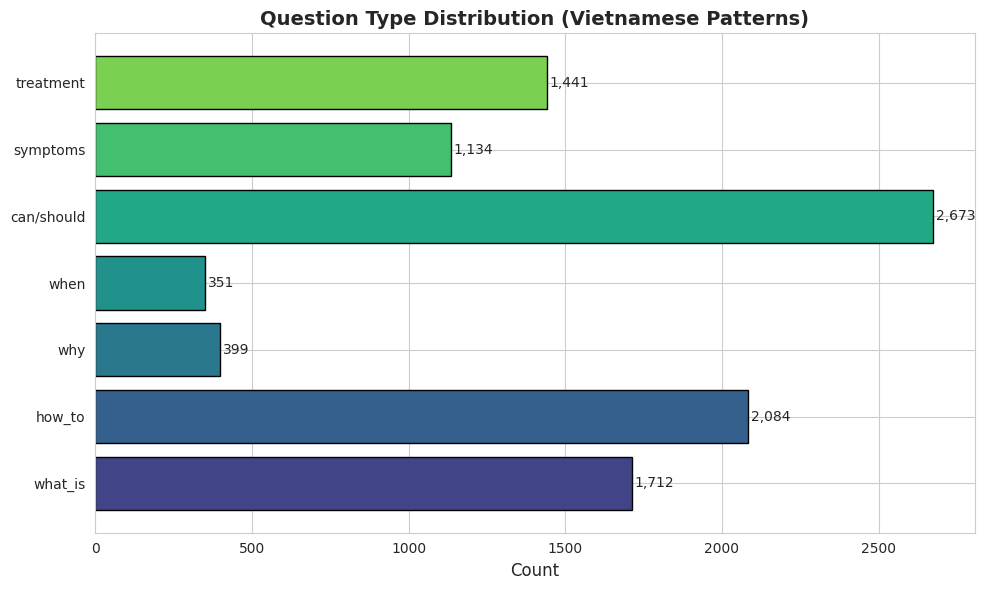


📊 Question Type Statistics:
   can/should: 2,673 (26.5%)
   how_to: 2,084 (20.7%)
   what_is: 1,712 (17.0%)
   treatment: 1,441 (14.3%)
   symptoms: 1,134 (11.2%)
   why: 399 (4.0%)
   when: 351 (3.5%)


In [66]:
# Extract user questions
user_questions = []
for entry in sft_data:
    for msg in entry['messages']:
        if msg['role'] == 'user':
            user_questions.append(msg['content'])

# Question type analysis (Vietnamese patterns)
question_patterns = {
    'what_is': r'(là gì|là sao|nghĩa là)',
    'how_to': r'(làm sao|làm thế nào|cách nào|như thế nào)',
    'why': r'(tại sao|vì sao|do đâu)',
    'when': r'(khi nào|bao giờ|lúc nào)',
    'can/should': r'(có thể|nên|có nên|được không)',
    'symptoms': r'(triệu chứng|dấu hiệu|biểu hiện)',
    'treatment': r'(điều trị|chữa|thuốc|phương pháp)'
}

pattern_counts = {pattern: 0 for pattern in question_patterns}

for q in user_questions:
    q_lower = q.lower()
    for pattern_name, regex in question_patterns.items():
        if re.search(regex, q_lower):
            pattern_counts[pattern_name] += 1

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

patterns = list(pattern_counts.keys())
counts = list(pattern_counts.values())

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(patterns)))
bars = ax.barh(patterns, counts, color=colors, edgecolor='black')

ax.set_xlabel('Count', fontsize=12)
ax.set_title('Question Type Distribution (Vietnamese Patterns)', fontsize=14, fontweight='bold')

# Add value labels
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 Question Type Statistics:")
for pattern, count in sorted(pattern_counts.items(), key=lambda x: x[1], reverse=True):
    pct = 100 * count / len(user_questions)
    print(f"   {pattern}: {count:,} ({pct:.1f}%)")

🔑 Top 20 Keywords in User Questions:
   nào: 3,054
   thể: 2,131
   bệnh: 2,061
   làm: 1,798
   không?: 1,728
   gì?: 1,677
   thế: 1,559
   nào?: 1,334
   chứng: 1,302
   điều: 1,187
   cần: 1,093
   nhân: 1,058
   viêm: 981
   trị: 936
   gây: 871
   triệu: 739
   phải: 738
   đau: 735
   sao: 725
   nguyên: 710


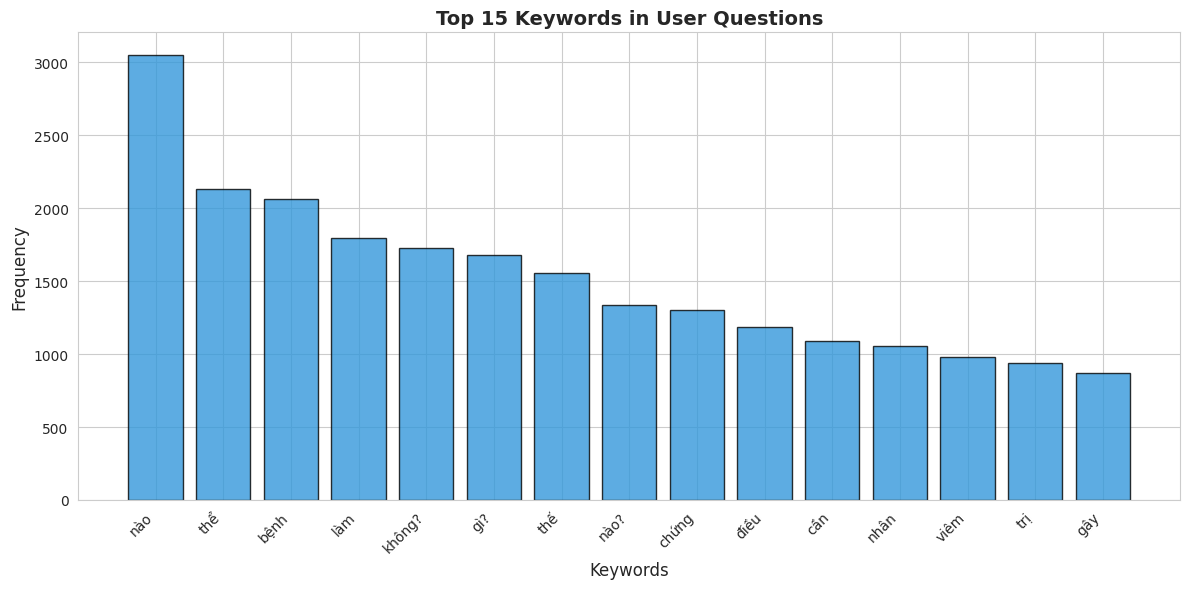

In [67]:
# Word frequency analysis (simplified)
from collections import Counter

# Common Vietnamese stop words
stop_words = {'và', 'của', 'là', 'có', 'được', 'trong', 'cho', 'với', 'các', 'này', 
              'đã', 'để', 'không', 'một', 'những', 'người', 'khi', 'như', 'theo', 'từ',
              'bị', 'tôi', 'bạn', 'thì', 'mà', 'nên', 'về', 'ra', 'lên', 'hay', 'hoặc',
              'cũng', 'vào', 'ở', 'trên', 'đến', 'sau', 'rồi', 'vì', 'do', 'nếu'}

# Extract words
all_words = []
for q in user_questions:
    words = q.lower().split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    all_words.extend(words)

word_freq = Counter(all_words)

# Top keywords
print("🔑 Top 20 Keywords in User Questions:")
for word, count in word_freq.most_common(20):
    print(f"   {word}: {count:,}")

# Visualize
top_words = word_freq.most_common(15)
words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(words, counts, color='#3498DB', edgecolor='black', alpha=0.8)
ax.set_xlabel('Keywords', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Top 15 Keywords in User Questions', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 9. Data Preprocessing Recommendations

### Dựa trên EDA, đề xuất các bước preprocessing:

1. **Text Cleaning**
   - Remove/replace URLs nếu cần
   - Clean HTML tags
   - Normalize whitespace

2. **Length Filtering**
   - Remove extremely short responses
   - Truncate or split very long conversations

3. **Duplicate Removal**
   - Remove exact duplicates
   - Consider near-duplicate detection

4. **Quality Enhancement**
   - Ensure consistent system prompts
   - Validate conversation structure

In [68]:
def preprocess_sft_data(data: list[dict], config: dict = None) -> list[dict]:
    """
    Preprocess SFT data based on EDA findings.
    
    Args:
        data: Raw SFT data
        config: Preprocessing configuration
        
    Returns:
        Cleaned data
    """
    if config is None:
        config = {
            'min_user_length': 5,
            'min_assistant_length': 10,
            'max_assistant_length': 5000,
            'remove_urls': False,
            'remove_html': False,
            'remove_duplicates': True
        }
    
    cleaned_data = []
    seen_hashes = set()
    
    stats = {
        'total': len(data),
        'removed_short': 0,
        'removed_long': 0,
        'removed_duplicate': 0,
        'cleaned_html': 0,
        'cleaned_urls': 0
    }
    
    for entry in data:
        skip = False
        cleaned_messages = []
        
        for msg in entry['messages']:
            content = msg['content']
            
            # Clean HTML
            if config['remove_html'] and re.search(r'<[^>]+>', content):
                content = re.sub(r'<[^>]+>', '', content)
                stats['cleaned_html'] += 1
            
            # Clean URLs (optional)
            if config['remove_urls'] and re.search(r'https?://\S+', content):
                content = re.sub(r'https?://\S+', '[URL]', content)
                stats['cleaned_urls'] += 1
            
            # Normalize whitespace while preserving newlines
            # Replace multiple spaces/tabs with single space, but keep \n
            content = re.sub(r'[^\S\n]+', ' ', content)  # Replace non-newline whitespace
            content = re.sub(r'\n{3,}', '\n\n', content)  # Limit consecutive newlines to 2
            content = content.strip()
            
            # Length checks
            if msg['role'] == 'user' and len(content) < config['min_user_length']:
                skip = True
                stats['removed_short'] += 1
                break
            
            if msg['role'] == 'assistant':
                if len(content) < config['min_assistant_length']:
                    skip = True
                    stats['removed_short'] += 1
                    break
                if len(content) > config['max_assistant_length']:
                    skip = True
                    stats['removed_long'] += 1
                    break
            
            cleaned_messages.append({'role': msg['role'], 'content': content})
        
        if skip:
            continue
        
        # Duplicate check
        if config['remove_duplicates']:
            conv_hash = hash(json.dumps(cleaned_messages, ensure_ascii=True))
            if conv_hash in seen_hashes:
                stats['removed_duplicate'] += 1
                continue
            seen_hashes.add(conv_hash)
        
        cleaned_data.append({'messages': cleaned_messages})
    
    stats['kept'] = len(cleaned_data)
    
    return cleaned_data, stats

# Run preprocessing (dry run)
cleaned_data, preprocess_stats = preprocess_sft_data(sft_data)

print("🧹 Preprocessing Results:")
print(f"   Original: {preprocess_stats['total']:,}")
print(f"   Kept: {preprocess_stats['kept']:,} ({100*preprocess_stats['kept']/preprocess_stats['total']:.1f}%)")
print(f"   Removed (short): {preprocess_stats['removed_short']}")
print(f"   Removed (long): {preprocess_stats['removed_long']}")
print(f"   Removed (duplicate): {preprocess_stats['removed_duplicate']}")
print(f"   Cleaned HTML: {preprocess_stats['cleaned_html']}")
print(f"   Cleaned URLs: {preprocess_stats['cleaned_urls']}")

🧹 Preprocessing Results:
   Original: 10,085
   Kept: 10,085 (100.0%)
   Removed (short): 0
   Removed (long): 0
   Removed (duplicate): 0
   Cleaned HTML: 0
   Cleaned URLs: 0


---
## 9.1 Extract Samples for Manual Review

### Thay vì remove các samples có vấn đề, extract ra file riêng để manual review:
- **Too long responses**: Cần rút gọn hoặc chia nhỏ
- **Too short responses**: Cần bổ sung thêm nội dung
- **Duplicates**: Cần review và merge/remove

### Workflow:
1. Extract samples có vấn đề → `tmp/sft_manual_review/`
2. Sửa manual các samples
3. Copy lại về file data gốc
4. Re-run preprocessing để verify

In [69]:
# Configuration for manual review extraction
REVIEW_CONFIG = {
    'max_assistant_length': 5000,  # Responses longer than this need review
    'min_assistant_length': 20,    # Responses shorter than this need review
    'min_user_length': 5,          # User messages shorter than this need review
    'extract_duplicates': True,    # Also extract duplicates for review
}

# Output directory
MANUAL_REVIEW_DIR = Path("../tmp/sft_manual_review")
MANUAL_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

def extract_samples_for_review(data: list[dict], config: dict) -> dict:
    """
    Extract samples that need manual review instead of removing them.
    
    Returns:
        Dictionary with categorized samples and their line numbers
    """
    review_samples = {
        'too_long': [],      # (line_number, entry)
        'too_short': [],     # (line_number, entry)
        'duplicates': [],    # (line_number, entry)
    }
    
    # Track for duplicate detection
    seen_hashes = {}  # hash -> first occurrence line number
    
    for idx, entry in enumerate(data, 1):  # 1-indexed line numbers
        for msg in entry['messages']:
            content = msg['content'].strip()
            
            # Check for too long assistant responses
            if msg['role'] == 'assistant' and len(content) > config['max_assistant_length']:
                review_samples['too_long'].append({
                    'line': idx,
                    'length': len(content),
                    'entry': entry
                })
                break
            
            # Check for too short responses
            if msg['role'] == 'assistant' and len(content) < config['min_assistant_length']:
                review_samples['too_short'].append({
                    'line': idx,
                    'length': len(content),
                    'entry': entry
                })
                break
            
            if msg['role'] == 'user' and len(content) < config['min_user_length']:
                review_samples['too_short'].append({
                    'line': idx,
                    'length': len(content),
                    'entry': entry
                })
                break
        
        # Check for duplicates
        if config['extract_duplicates']:
            conv_hash = hash(json.dumps(entry['messages'], ensure_ascii=False))
            if conv_hash in seen_hashes:
                # This is a duplicate
                review_samples['duplicates'].append({
                    'line': idx,
                    'duplicate_of_line': seen_hashes[conv_hash],
                    'entry': entry
                })
            else:
                seen_hashes[conv_hash] = idx
    
    return review_samples

# Extract samples for review
review_samples = extract_samples_for_review(sft_data, REVIEW_CONFIG)

print("🔍 Samples Extracted for Manual Review:")
print(f"   📏 Too long (>{REVIEW_CONFIG['max_assistant_length']} chars): {len(review_samples['too_long'])}")
print(f"   📏 Too short (<{REVIEW_CONFIG['min_assistant_length']} chars): {len(review_samples['too_short'])}")
print(f"   🔄 Duplicates: {len(review_samples['duplicates'])}")

🔍 Samples Extracted for Manual Review:
   📏 Too long (>5000 chars): 0
   📏 Too short (<20 chars): 0
   🔄 Duplicates: 0


In [70]:
# Print detailed info about samples needing review
def print_review_details(review_samples: dict):
    """Print detailed information about samples needing manual review."""
    
    # Too Long Samples
    if review_samples['too_long']:
        print("\n" + "="*80)
        print("📏 TOO LONG RESPONSES - Need to shorten/split")
        print("="*80)
        print(f"{'Line':<8} {'Length':<10} {'Preview (first 100 chars)'}")
        print("-"*80)
        for item in review_samples['too_long']:
            # Get assistant content
            assistant_content = ""
            for msg in item['entry']['messages']:
                if msg['role'] == 'assistant':
                    assistant_content = msg['content']
                    break
            preview = assistant_content[:100].replace('\n', ' ') + "..."
            print(f"{item['line']:<8} {item['length']:<10} {preview}")
    
    # Too Short Samples
    if review_samples['too_short']:
        print("\n" + "="*80)
        print("📏 TOO SHORT RESPONSES - Need to expand")
        print("="*80)
        print(f"{'Line':<8} {'Length':<10} {'Content'}")
        print("-"*80)
        for item in review_samples['too_short'][:20]:  # Show first 20
            # Get the short content
            for msg in item['entry']['messages']:
                if len(msg['content'].strip()) < 20:
                    content = msg['content'].strip().replace('\n', ' ')
                    print(f"{item['line']:<8} {item['length']:<10} {content}")
                    break
        if len(review_samples['too_short']) > 20:
            print(f"... and {len(review_samples['too_short']) - 20} more")
    
    # Duplicates
    if review_samples['duplicates']:
        print("\n" + "="*80)
        print("🔄 DUPLICATES - Need to merge or remove")
        print("="*80)
        print(f"{'Line':<8} {'Duplicate of':<15} {'Preview'}")
        print("-"*80)
        for item in review_samples['duplicates'][:20]:  # Show first 20
            # Get user question as preview
            user_content = ""
            for msg in item['entry']['messages']:
                if msg['role'] == 'user':
                    user_content = msg['content'][:60].replace('\n', ' ')
                    break
            print(f"{item['line']:<8} Line {item['duplicate_of_line']:<10} {user_content}...")
        if len(review_samples['duplicates']) > 20:
            print(f"... and {len(review_samples['duplicates']) - 20} more")

# Print details
print_review_details(review_samples)

In [45]:
# Export samples to separate files for manual review
def export_for_manual_review(review_samples: dict, output_dir: Path, original_file: Path):
    """
    Export samples needing review to separate JSONL files.
    Also creates a clean version of the original file without these samples.
    
    Files created:
    - sft_too_long.jsonl: Samples with too long responses
    - sft_too_short.jsonl: Samples with too short responses  
    - sft_duplicates.jsonl: Duplicate samples
    - sft_lines_to_review.txt: List of line numbers to review
    """
    
    # Collect all line numbers that need review
    lines_to_review = set()
    
    # Export too long samples
    if review_samples['too_long']:
        filepath = output_dir / "sft_too_long.jsonl"
        with open(filepath, 'w', encoding='utf-8') as f:
            for item in review_samples['too_long']:
                lines_to_review.add(item['line'])
                # Add metadata as comment
                output = {
                    '_metadata': {
                        'original_line': item['line'],
                        'issue': 'too_long',
                        'length': item['length']
                    },
                    **item['entry']
                }
                f.write(json.dumps(output, ensure_ascii=False) + '\n')
        print(f"✅ Exported {len(review_samples['too_long'])} too-long samples to {filepath}")
    
    # Export too short samples
    if review_samples['too_short']:
        filepath = output_dir / "sft_too_short.jsonl"
        with open(filepath, 'w', encoding='utf-8') as f:
            for item in review_samples['too_short']:
                lines_to_review.add(item['line'])
                output = {
                    '_metadata': {
                        'original_line': item['line'],
                        'issue': 'too_short',
                        'length': item['length']
                    },
                    **item['entry']
                }
                f.write(json.dumps(output, ensure_ascii=False) + '\n')
        print(f"✅ Exported {len(review_samples['too_short'])} too-short samples to {filepath}")
    
    # Export duplicates
    if review_samples['duplicates']:
        filepath = output_dir / "sft_duplicates.jsonl"
        with open(filepath, 'w', encoding='utf-8') as f:
            for item in review_samples['duplicates']:
                lines_to_review.add(item['line'])
                output = {
                    '_metadata': {
                        'original_line': item['line'],
                        'issue': 'duplicate',
                        'duplicate_of_line': item['duplicate_of_line']
                    },
                    **item['entry']
                }
                f.write(json.dumps(output, ensure_ascii=False) + '\n')
        print(f"✅ Exported {len(review_samples['duplicates'])} duplicate samples to {filepath}")
    
    # Export list of line numbers
    lines_file = output_dir / "sft_lines_to_review.txt"
    with open(lines_file, 'w') as f:
        f.write("# Line numbers in original file that need manual review\n")
        f.write(f"# Original file: {original_file}\n")
        f.write(f"# Total lines to review: {len(lines_to_review)}\n\n")
        for line in sorted(lines_to_review):
            f.write(f"{line}\n")
    print(f"✅ Line numbers saved to {lines_file}")
    
    # Create clean version (without problematic samples)
    clean_filepath = output_dir / "sft_clean.jsonl"
    with open(original_file, 'r', encoding='utf-8') as f_in:
        with open(clean_filepath, 'w', encoding='utf-8') as f_out:
            for idx, line in enumerate(f_in, 1):
                if idx not in lines_to_review:
                    f_out.write(line)
    
    clean_count = len(sft_data) - len(lines_to_review)
    print(f"✅ Clean data ({clean_count} samples) saved to {clean_filepath}")
    
    return lines_to_review

# Export files
print("\n📤 Exporting samples for manual review...")
print(f"📁 Output directory: {MANUAL_REVIEW_DIR.absolute()}\n")

lines_to_review = export_for_manual_review(
    review_samples, 
    MANUAL_REVIEW_DIR, 
    DATA_PATH
)

print(f"\n📊 Summary:")
print(f"   Total samples needing review: {len(lines_to_review)}")
print(f"   Clean samples: {len(sft_data) - len(lines_to_review)}")


📤 Exporting samples for manual review...
📁 Output directory: /home/minhquana/workspace/project_LargeLanguageModel/ViMed-Assistant-With-Preference-Alignment/notebooks/../tmp/sft_manual_review

✅ Exported 5 too-long samples to ../tmp/sft_manual_review/sft_too_long.jsonl
✅ Exported 92 duplicate samples to ../tmp/sft_manual_review/sft_duplicates.jsonl
✅ Line numbers saved to ../tmp/sft_manual_review/sft_lines_to_review.txt
✅ Clean data (7127 samples) saved to ../tmp/sft_manual_review/sft_clean.jsonl

📊 Summary:
   Total samples needing review: 97
   Clean samples: 7127


### 📝 Manual Review Workflow

Sau khi export, thực hiện các bước sau:

1. **Review các file trong `tmp/sft_manual_review/`:**
   - `sft_too_long.jsonl` - Rút gọn các responses quá dài
   - `sft_too_short.jsonl` - Bổ sung thêm nội dung
   - `sft_duplicates.jsonl` - Quyết định giữ/xóa duplicates

2. **Sau khi sửa xong:**
   - Remove trường `_metadata` khỏi các entries
   - Merge các entries đã sửa vào file gốc theo line number

3. **Merge lại vào file gốc:**
   - Chạy cell bên dưới để merge

In [47]:
# Function to merge reviewed samples back to original file
def merge_reviewed_samples(
    original_file: Path,
    review_dir: Path,
    output_file: Path,
    remove_duplicates: bool = True
):
    """
    Merge manually reviewed samples back into the dataset.
    
    Args:
        original_file: Path to original JSONL file
        review_dir: Directory containing reviewed files
        output_file: Path for the merged output file
        remove_duplicates: Whether to remove duplicate entries (keep only first occurrence)
    """
    # Load reviewed samples with their line numbers
    reviewed = {}  # line_number -> entry
    files_to_check = [
        'sft_too_long.jsonl',
        'sft_too_short.jsonl',
    ]
    
    # Load reviewed files (duplicates are typically removed, not merged back)
    for filename in files_to_check:
        filepath = review_dir / filename
        if filepath.exists():
            with open(filepath, 'r', encoding='utf-8') as f:
                for line in f:
                    entry = json.loads(line.strip())
                    if '_metadata' in entry:
                        line_num = entry['_metadata']['original_line']
                        # Remove metadata before saving
                        del entry['_metadata']
                        reviewed[line_num] = entry
            print(f"📖 Loaded {len(reviewed)} entries from {filename}")
    
    # Get duplicate line numbers to remove
    duplicates_to_remove = set()
    if remove_duplicates:
        dup_file = review_dir / 'sft_duplicates.jsonl'
        if dup_file.exists():
            with open(dup_file, 'r', encoding='utf-8') as f:
                for line in f:
                    entry = json.loads(line.strip())
                    if '_metadata' in entry:
                        duplicates_to_remove.add(entry['_metadata']['original_line'])
            print(f"🔄 Found {len(duplicates_to_remove)} duplicates to remove")
    
    # Merge back
    merged_count = 0
    removed_count = 0
    
    with open(original_file, 'r', encoding='utf-8') as f_in:
        with open(output_file, 'w', encoding='utf-8') as f_out:
            for idx, line in enumerate(f_in, 1):
                # Skip duplicates
                if idx in duplicates_to_remove:
                    removed_count += 1
                    continue
                
                # Use reviewed version if available
                if idx in reviewed:
                    f_out.write(json.dumps(reviewed[idx], ensure_ascii=False) + '\n')
                    merged_count += 1
                else:
                    f_out.write(line)
    
    print(f"\n✅ Merge complete!")
    print(f"   Merged reviewed entries: {merged_count}")
    print(f"   Removed duplicates: {removed_count}")
    print(f"   Output file: {output_file}")

# Uncomment and run after manual review is complete
merge_reviewed_samples(
    original_file=DATA_PATH,
    review_dir=MANUAL_REVIEW_DIR,
    output_file=Path("../data/final_sft_reviewed.jsonl"),
    remove_duplicates=True
)

📖 Loaded 5 entries from sft_too_long.jsonl
🔄 Found 92 duplicates to remove

✅ Merge complete!
   Merged reviewed entries: 5
   Removed duplicates: 92
   Output file: ../data/final_sft_reviewed.jsonl


In [48]:
cleaned_data[-1]

{'messages': [{'role': 'system',
   'content': 'Bạn là một trợ lý y tế ảo thông minh, với vai trò là một bác sĩ tư vấn trực tuyến chuyên nghiệp và tận tâm. Nhiệm vụ của bạn là giải đáp thắc mắc, câu hỏi về chủ đề y tế. Câu trả lời cần mang tính định hướng, giải thích nguyên nhân có thể, không được thay thế chẩn đoán của bệnh viện và phải luôn khuyên người dùng đến cơ sở y tế để có chẩn đoán chính xác.'},
  {'role': 'user',
   'content': 'Những biểu hiện ngoài da nào có thể liên quan đến bệnh tiểu đường?'},
  {'role': 'assistant',
   'content': 'Khoảng 30-70% bệnh nhân tiểu đường có biểu hiện ngoài da. Các dấu hiệu thường gặp bao gồm:\n1. Bệnh da do tiểu đường: Các đốm nâu đỏ ở mặt trước cẳng chân (do bệnh lý mạch máu nhỏ).\n2. Chứng gai đen (Acanthosis Nigricans): Vùng da sẫm màu, mịn như nhung ở nếp gấp cổ, nách (dấu hiệu kháng insulin).\n3. Nhiễm trùng da: Dễ bị nấm (Candida gây viêm kẽ, nấm móng), hoặc nhiễm khuẩn (nhọt, viêm mô tế bào). Đặc biệt lưu ý loét bàn chân tiểu đường.\n4. 

---
## 10. Export Cleaned Data (Optional)

Sau khi preprocessing, có thể export data đã clean để sử dụng cho training.

In [50]:
# Export function
def export_cleaned_data(data: list[dict], output_path: Path):
    """
    Export cleaned SFT data to JSONL file.
    """
    with open(output_path, 'w', encoding='utf-8') as f:
        for entry in data:
            f.write(json.dumps(entry, ensure_ascii=False) + '\n')
    print(f"✅ Exported {len(data):,} entries to {output_path}")

# Uncomment to export
OUTPUT_PATH = Path("../data/final_sft_cleaned.jsonl")
export_cleaned_data(cleaned_data, OUTPUT_PATH)

✅ Exported 7,126 entries to ../data/final_sft_cleaned.jsonl


---
## 📋 Summary & Recommendations

### Key Findings:
1. **Dataset Size**: Số lượng conversations và distribution
2. **Text Lengths**: Phân bố độ dài phù hợp cho SFT
3. **Quality Issues**: Các vấn đề cần xử lý trước training
4. **Content Analysis**: Chủ đề và patterns trong data

### Preprocessing Checklist:
- [X] Remove duplicates
- [X] Filter short/empty responses
- [X] Clean special characters
- [X] Normalize system prompts
- [X] Set appropriate max_length

### Training Recommendations:
- `max_length`: Dựa trên 99th percentile của token distribution
- Sử dụng chat template phù hợp với model
- Consider gradient checkpointing cho long sequences

In [127]:
# Final summary
print("="*60)
print("📊 SFT DATASET EDA SUMMARY")
print("="*60)
print(f"\n📁 Dataset: {DATA_PATH}")
print(f"📝 Total conversations: {len(sft_data):,}")
print(f"💬 Avg messages/conversation: {np.mean(stats['num_messages']):.1f}")
print(f"📏 Avg user message length: {np.mean(length_data['user']['char']):.0f} chars")
print(f"📏 Avg assistant response length: {np.mean(length_data['assistant']['char']):.0f} chars")
if token_counts:
    print(f"🔢 Avg tokens/conversation: {np.mean(token_counts):.0f}")
    print(f"🔢 Recommended max_length: {int(np.percentile(token_counts, 99))}")
print(f"\n✅ Ready for SFT training!")
print("="*60)

📊 SFT DATASET EDA SUMMARY

📁 Dataset: ../data/final_sft_cleaned.jsonl
📝 Total conversations: 7,124
💬 Avg messages/conversation: 3.0
📏 Avg user message length: 66 chars
📏 Avg assistant response length: 695 chars
🔢 Avg tokens/conversation: 333
🔢 Recommended max_length: 971

✅ Ready for SFT training!
